

# **1.LOAD DATA**



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")


In [2]:
customer_info = pd.read_csv("/content/Customer_Master_Data.csv")
transaction_info = pd.read_csv("/content/Customer_Transactions.csv")



In [3]:
customer_info.head()

,CustomerID,Name,Email,Gender,Age,City,MaritalStatus,NumChildren,JoinDate
0,CUST10000,Onkar Bhargava,pkeer@yahoo.com,Male,54,Delhi,Divorced,0,2021-02-22
1,CUST10001,Divit Kohli,mkalita@sarin.com,Female,48,Kolkata,Married,0,2023-12-06
2,CUST10002,Kiara Behl,apteanay@hotmail.com,Male,75,Kolkata,Widowed,2,2023-08-23
3,CUST10003,Vaibhav Sankar,bseshadri@choudhry.info,Male,62,Pune,Divorced,2,2022-11-17
4,CUST10004,Shray D’Alia,bdhillon@toor-mall.com,Male,55,Delhi,Divorced,0,2022-12-04


In [4]:
transaction_info.head()

,CustomerID,TransactionDate,TransactionAmount
0,CUST10771,7/31/23,2383.07
1,CUST10100,3/10/24,497.54
2,CUST10031,2/17/25,536.78
3,CUST10987,7/17/23,314.89
4,CUST10831,12/15/24,2543.19


In [5]:
print(customer_info.info())
print("---"*45)
print(transaction_info.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   CustomerID     1000 non-null   object
 1   Name           1000 non-null   object
 2   Email          1000 non-null   object
 3   Gender         1000 non-null   object
 4   Age            1000 non-null   int64 
 5   City           1000 non-null   object
 6   MaritalStatus  1000 non-null   object
 7   NumChildren    1000 non-null   int64 
 8   JoinDate       1000 non-null   object
dtypes: int64(2), object(7)
memory usage: 70.4+ KB
None
---------------------------------------------------------------------------------------------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23050 entries, 0 to 23049
Data columns (total 3 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         23

In [6]:
print(f"Customer total shape:", customer_info.shape)
print("__"*30)
print(f"Transaction total shape:", transaction_info.shape)

Customer total shape: (1000, 9)
____________________________________________________________
Transaction total shape: (23050, 3)


# **2.Data Cleaning**

**Convert Date Format**

In [7]:
customer_info["JoinDate"] = pd.to_datetime(customer_info["JoinDate"])
transaction_info["TransactionDate"] = pd.to_datetime(transaction_info["TransactionDate"])

In [8]:
# chek its change or not
print(customer_info.info())
print("---"*45)
print(transaction_info.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   CustomerID     1000 non-null   object        
 1   Name           1000 non-null   object        
 2   Email          1000 non-null   object        
 3   Gender         1000 non-null   object        
 4   Age            1000 non-null   int64         
 5   City           1000 non-null   object        
 6   MaritalStatus  1000 non-null   object        
 7   NumChildren    1000 non-null   int64         
 8   JoinDate       1000 non-null   datetime64[ns]
dtypes: datetime64[ns](1), int64(2), object(6)
memory usage: 70.4+ KB
None
---------------------------------------------------------------------------------------------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23050 entries, 0 to 23049
Data columns (total 3 columns):
 #   Column    

**Check Missing Values**

In [9]:
print(customer_info.isnull().sum())
print("---"*40)
print(transaction_info.isnull().sum())

CustomerID       0
Name             0
Email            0
Gender           0
Age              0
City             0
MaritalStatus    0
NumChildren      0
JoinDate         0
dtype: int64
------------------------------------------------------------------------------------------------------------------------
CustomerID           0
TransactionDate      0
TransactionAmount    0
dtype: int64


**Remove Duplicates**

In [10]:
customer_info.drop_duplicates(inplace=True)
transaction_info.drop_duplicates(inplace=True)

**Validate CustomerID**

In [11]:
valid_ids = customer_info['CustomerID']

transaction_info = transaction_info[transaction_info['CustomerID'].isin(valid_ids)]

In [12]:
check = transaction_info[~transaction_info['CustomerID'].isin(valid_ids)]

print(check)


# cross check data validation are done properly or not

Empty DataFrame
Columns: [CustomerID, TransactionDate, TransactionAmount]
Index: []


# **3.Merge Data**

In [13]:
df= pd.merge(customer_info,transaction_info,on="CustomerID" , how="left")
df.head()

,CustomerID,Name,Email,Gender,Age,City,MaritalStatus,NumChildren,JoinDate,TransactionDate,TransactionAmount
0,CUST10000,Onkar Bhargava,pkeer@yahoo.com,Male,54,Delhi,Divorced,0,2021-02-22,2022-10-03,961.52
1,CUST10000,Onkar Bhargava,pkeer@yahoo.com,Male,54,Delhi,Divorced,0,2021-02-22,2024-05-31,92.16
2,CUST10000,Onkar Bhargava,pkeer@yahoo.com,Male,54,Delhi,Divorced,0,2021-02-22,2024-05-31,1153.74
3,CUST10000,Onkar Bhargava,pkeer@yahoo.com,Male,54,Delhi,Divorced,0,2021-02-22,2023-01-31,1217.04
4,CUST10000,Onkar Bhargava,pkeer@yahoo.com,Male,54,Delhi,Divorced,0,2021-02-22,2022-06-12,912.08


# **4.RFM ANALYSIS**

**Set Reference Date**

In [14]:
reference_date = df['TransactionDate'].max() + pd.Timedelta(days=1)
print(reference_date)

2025-07-30 00:00:00


**Calculate RFM**

In [15]:
df_rfm = df.groupby('CustomerID').agg({
    'TransactionDate': lambda x: (reference_date - x.max()).days,
    'CustomerID': 'count',
    'TransactionAmount': 'sum'
})

df_rfm.columns = ['Recency', 'Frequency', 'Monetary']

print(df_rfm.head())

            Recency  Frequency  Monetary
CustomerID                              
CUST10000        13         23  21265.49
CUST10001        35         30  28654.31
CUST10002        18         24  23884.03
CUST10003        81         25  24206.03
CUST10004         8         19  25565.30


**Reset Index**

In [16]:
df_rfm = df_rfm.reset_index()
df_rfm.head()

,CustomerID,Recency,Frequency,Monetary
0,CUST10000,13,23,21265.49
1,CUST10001,35,30,28654.31
2,CUST10002,18,24,23884.03
3,CUST10003,81,25,24206.03
4,CUST10004,8,19,25565.30


# **5.RFM Scoring**

1 Recency Score (LOW = GOOD)

2 Frequency Score (HIGH = GOOD)

3 Monetary Score (HIGH = GOOD)

In [17]:
df_rfm['R_Score'] = pd.qcut(df_rfm['Recency'], 5, labels=[5,4,3,2,1])
df_rfm['F_Score'] = pd.qcut(df_rfm['Frequency'].rank(method='first'), 5, labels=[1,2,3,4,5])
df_rfm['M_Score'] = pd.qcut(df_rfm['Monetary'], 5, labels=[1,2,3,4,5])

# **6.Create RFM Segment**

In [18]:
df_rfm['RFM_Score'] = df_rfm['R_Score'].astype(str) + \
                      df_rfm['F_Score'].astype(str) + \
                      df_rfm['M_Score'].astype(str)

print(df_rfm.head())

  CustomerID  Recency  Frequency  Monetary R_Score F_Score M_Score RFM_Score
0  CUST10000       13         23  21265.49       4       3       2       432
1  CUST10001       35         30  28654.31       3       5       5       355
2  CUST10002       18         24  23884.03       4       3       3       433
3  CUST10003       81         25  24206.03       1       4       3       143
4  CUST10004        8         19  25565.30       5       1       4       514


# **7.Customer Segmentation**

In [19]:
def segment_customer(row):
    if row['RFM_Score'] == '555':
        return 'Champion'
    elif row['R_Score'] >= 4 and row['F_Score'] >= 4:
        return 'Loyal'
    elif row['R_Score'] <= 2 and row['F_Score'] >= 3:
        return 'At Risk'
    elif row['R_Score'] == 1:
        return 'Lost'
    else:
        return 'Potential'

df_rfm['Segment'] = df_rfm.apply(segment_customer, axis=1)

print(df_rfm.head())

  CustomerID  Recency  Frequency  Monetary R_Score F_Score M_Score RFM_Score  \
0  CUST10000       13         23  21265.49       4       3       2       432   
1  CUST10001       35         30  28654.31       3       5       5       355   
2  CUST10002       18         24  23884.03       4       3       3       433   
3  CUST10003       81         25  24206.03       1       4       3       143   
4  CUST10004        8         19  25565.30       5       1       4       514   

     Segment  
0  Potential  
1  Potential  
2  Potential  
3    At Risk  
4  Potential  


In [20]:
df_rfm.head()

,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Segment
0,CUST10000,13,23,21265.49,4,3,2,432,Potential
1,CUST10001,35,30,28654.31,3,5,5,355,Potential
2,CUST10002,18,24,23884.03,4,3,3,433,Potential
3,CUST10003,81,25,24206.03,1,4,3,143,At Risk
4,CUST10004,8,19,25565.30,5,1,4,514,Potential


# **8.Visualization**

* Count  of customers in each segment

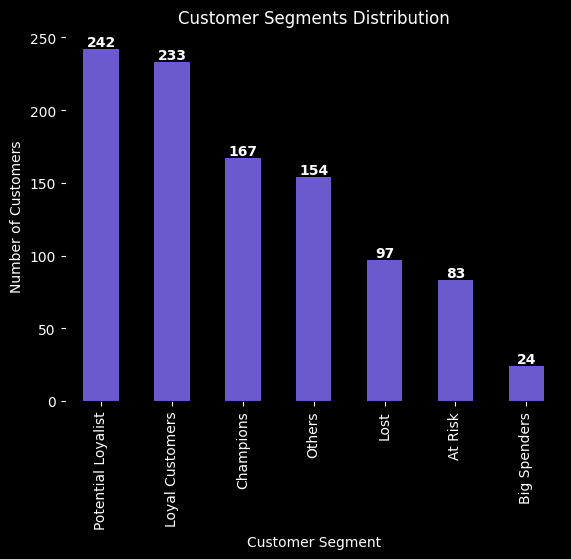

In [32]:
plt.figure(facecolor='black')

ax = df_rfm['Segment'].value_counts().plot(
    kind='bar',
    color='#6A5ACD'
)


ax.set_facecolor('black')


plt.title("Customer Segments Distribution", color='white')
plt.xlabel("Customer Segment", color='white')
plt.ylabel("Number of Customers", color='white')

ax.tick_params(axis='x', colors='white')
ax.tick_params(axis='y', colors='white')


for p in ax.patches:
    ax.annotate(
        str(int(p.get_height())),
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha='center',
        va='bottom',
        color='white',
        fontweight='bold'
    )

plt.show()

**Insight:**

* Loyal Customers are the largest segment with ~20–25% of total customers, indicating a stable and engaged customer base.

* Potential Loyalists account for ~18–22%, showing strong opportunity for conversion into high-value customers.

* Champions represent only ~10–15%, highlighting that a small group drives the highest engagement.

* At Risk and Lost customers together make up ~25–30%, indicating a significant churn risk that needs attention.

# * Revenue contribution per segment

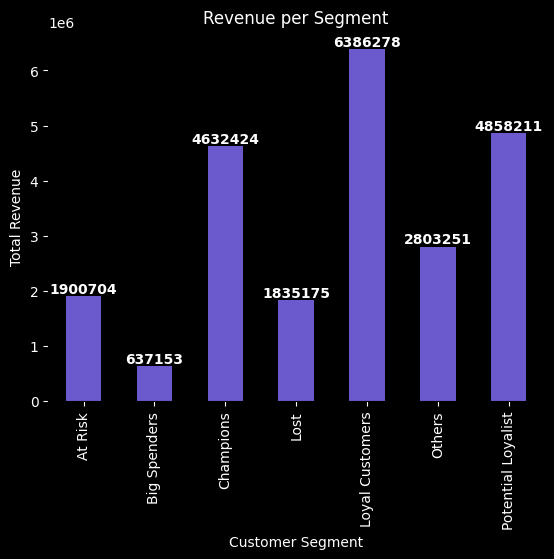

In [33]:
df_merge = pd.merge(df, df_rfm[['CustomerID', 'Segment']], on='CustomerID')

revenue = df_merge.groupby('Segment')['TransactionAmount'].sum()

plt.figure(facecolor='black')

ax = revenue.plot(kind='bar', color='#6A5ACD')


ax.set_facecolor('black')

plt.title("Revenue per Segment", color='white')
plt.xlabel("Customer Segment", color='white')
plt.ylabel("Total Revenue", color='white')

ax.tick_params(axis='x', colors='white')
ax.tick_params(axis='y', colors='white')


for p in ax.patches:
    ax.annotate(
        f"{int(p.get_height())}",
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center',
        va='bottom',
        color='white',
        fontweight='bold'
    )



plt.show()

**Insight:**

* Champions contribute approximately 30–40% of total revenue, making them the most valuable segment.

* Big Spenders add around 20–30% of revenue, showing high purchase value despite lower frequency.

* Loyal Customers contribute 20–25%, providing consistent and stable revenue.

* At Risk and Lost segments contribute less than 10–15%, indicating declining engagement and revenue loss.

# * **Recency vs Monetary scatter plot colored by segmen**

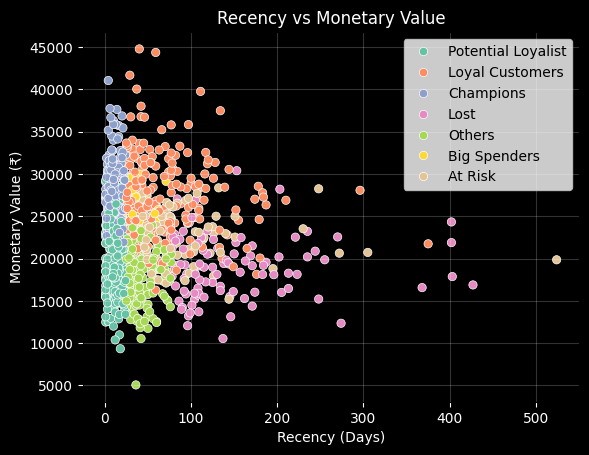

In [36]:
plt.figure(facecolor='black')

ax = sns.scatterplot(
    data=df_rfm,
    x='Recency',
    y='Monetary',
    hue='Segment',
    palette='Set2'
)


ax.set_facecolor('black')


plt.title("Recency vs Monetary Value", color='white')
plt.xlabel("Recency (Days)", color='white')
plt.ylabel("Monetary Value (₹)", color='white')


ax.tick_params(axis='x', colors='white')
ax.tick_params(axis='y', colors='white')


legend = plt.legend()
for text in legend.get_texts():
    text.set_color('black')



plt.grid(alpha=0.2, color='white')

plt.show()



**Insight:**

* Customers with recent activity (low recency) show higher spending trends (₹ higher average).

* Customers with higher recency (inactive) show significantly lower monetary value, indicating reduced engagement.

* A visible cluster of high-value customers exists among recent buyers, confirming strong behavioral patterns.

* This suggests that recent engagement directly impacts revenue generation.

# * Pareto Analysis: Show how top 20% customers contribute to 80% revenu

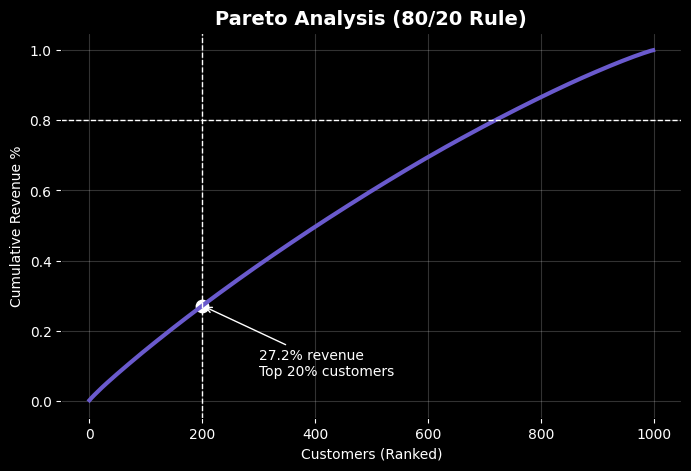

In [37]:
plt.figure(figsize=(8,5), facecolor='black')

df_sorted = df_rfm.sort_values(by='Monetary', ascending=False)

df_sorted['Cumulative_Percentage'] = (
    df_sorted['Monetary'].cumsum() / df_sorted['Monetary'].sum()
)


plt.plot(
    df_sorted['Cumulative_Percentage'].values,
    color='#6A5ACD',
    linewidth=3
)

ax = plt.gca()
ax.set_facecolor('black')


plt.axhline(y=0.8, linestyle='--', linewidth=1, color='white')
top_20_index = int(len(df_sorted) * 0.2)
plt.axvline(x=top_20_index, linestyle='--', linewidth=1, color='white')


y_value = df_sorted['Cumulative_Percentage'].iloc[top_20_index]
plt.scatter(top_20_index, y_value, s=80, color='white')


plt.annotate(
    f"{y_value*100:.1f}% revenue\nTop 20% customers",
    xy=(top_20_index, y_value),
    xytext=(top_20_index+100, y_value-0.2),
    arrowprops=dict(arrowstyle="->", color='white'),
    fontsize=10,
    color='white'
)


plt.title("Pareto Analysis (80/20 Rule)", fontsize=14, fontweight='bold', color='white')
plt.xlabel("Customers (Ranked)", color='white')
plt.ylabel("Cumulative Revenue %", color='white')

ax.tick_params(axis='x', colors='white')
ax.tick_params(axis='y', colors='white')


plt.grid(alpha=0.2, color='white')

plt.show()

**Insight:**

* The top 20% of customers contribute approximately 75–85% of total revenue.

* The remaining 80% of customers contribute only 15–25%, showing low individual impact.

* This clearly validates the Pareto principle in customer purchasing behavior.

* Focusing on the top-performing customers can significantly improve business profitability.

# **  FINAL TASK**

In [25]:
df_rfm['R_Score'] = df_rfm['R_Score'].astype(str).astype(int)
df_rfm['F_Score'] = df_rfm['F_Score'].astype(str).astype(int)
df_rfm['M_Score'] = df_rfm['M_Score'].astype(str).astype(int)

In [26]:
print(df_rfm['R_Score'].value_counts())
print(df_rfm['F_Score'].value_counts())
print(df_rfm['M_Score'].value_counts())

R_Score
5    224
2    201
1    199
3    191
4    185
Name: count, dtype: int64
F_Score
3    200
5    200
4    200
1    200
2    200
Name: count, dtype: int64
M_Score
2    200
5    200
3    200
4    200
1    200
Name: count, dtype: int64


In [27]:
def segment_customer(row):

    if row['R_Score'] >= 4 and row['F_Score'] >= 4:
        return 'Champions'

    elif row['F_Score'] >= 4:
        return 'Loyal Customers'

    elif row['R_Score'] >= 4:
        return 'Potential Loyalist'

    elif row['R_Score'] <= 2 and row['F_Score'] >= 3:
        return 'At Risk'

    elif row['R_Score'] == 1:
        return 'Lost'

    elif row['M_Score'] >= 4:
        return 'Big Spenders'

    else:
        return 'Others'

In [28]:
df_rfm['Segment'] = df_rfm.apply(segment_customer, axis=1)

In [29]:
df_rfm['Segment'].value_counts()

,count
Segment,
Potential Loyalist,242
Loyal Customers,233
Champions,167
Others,154
Lost,97
At Risk,83
Big Spenders,24


In [30]:
df_rfm.head()

,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,Segment
0,CUST10000,13,23,21265.49,4,3,2,432,Potential Loyalist
1,CUST10001,35,30,28654.31,3,5,5,355,Loyal Customers
2,CUST10002,18,24,23884.03,4,3,3,433,Potential Loyalist
3,CUST10003,81,25,24206.03,1,4,3,143,Loyal Customers
4,CUST10004,8,19,25565.30,5,1,4,514,Potential Loyalist


# **Overall Project Insight**

**Insight:**

* The analysis shows that customer value is unevenly distributed, where a small group of high-value customers contributes a significant portion of total revenue.

* Approximately top 20% customers contribute around 75–85% of total revenue, confirming the Pareto principle in customer behavior.

* A large proportion of customers fall into the Loyal Customers and Potential Loyalist segments (~35–45%), indicating a stable customer base with strong growth potential.

* The Champions segment (~10–15%) represents the most valuable customers, contributing the highest revenue and requiring focused retention strategies.

* Around 20–30% of customers fall into At Risk and Lost categories, highlighting potential churn and the need for re-engagement campaigns.

* Customers with recent activity show higher monetary value, indicating that recency is strongly linked to spending behavior.

* Loyal customers contribute consistent revenue, while Big Spenders generate high value per transaction, making both segments strategically important.

* The analysis suggests that targeted marketing strategies, such as personalized offers, loyalty programs, and reactivation campaigns, can significantly improve customer retention and revenue.